# Ken French Data Library

**Source:** https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

This notebook explains what the French Data Library is, what it contains, how to load it with our new `FrenchDataLoader`, and — critically — **which datasets are most relevant for cross-sectional return prediction**.

---

## What is it?

The Ken French Data Library (maintained by Professor Kenneth R. French at Tuck School of Business, Dartmouth) is the most widely used publicly available dataset in academic and practitioner equity research. It provides:

1. **Factor return series** — the canonical long/short portfolio returns for the Fama-French factors (market, size, value, profitability, investment) and momentum, going back as far as 1926.

2. **Portfolio sorts** — pre-constructed portfolios sorted by characteristics (size, book-to-market, momentum, etc.). These are the standard *test assets* used to evaluate cross-sectional asset pricing models.

All data are freely downloadable as ZIP/CSV files and updated regularly (typically monthly).

### Why it matters for research

Every cross-sectional return prediction paper uses this data in at least one of three ways:
- **Attribution**: How much of a strategy's alpha survives after controlling for Fama-French factors?
- **Signal construction**: The factor definitions (SMB, HML, Mom…) are the reference implementations of "size", "value", "momentum" signals.
- **Test assets**: The 25 size/BM portfolios and 10 momentum deciles are the standard benchmarks against which asset pricing models are evaluated.

---

## Dataset taxonomy

The library has ~100 datasets across two broad categories:

| Category | What it contains | Use case |
|----------|-----------------|----------|
| **Factor returns** | Daily/monthly/annual time series for each factor (e.g. SMB = long small-cap, short large-cap) | Risk attribution, alpha measurement, feature construction |
| **Portfolio sorts** | Returns of portfolios formed by sorting on one or two characteristics | Testing whether a characteristic predicts returns cross-sectionally |

### Factor return datasets (most relevant for us)

| Dataset | Factors | Period | Key use |
|---------|---------|--------|---------|
| **Fama/French 3 Factors** | Mkt-RF, SMB, HML, RF | 1926–present | Classic benchmark; risk-free rate source |
| **Fama/French 5 Factors (2x3)** | + RMW, CMA | 1963–present | Modern baseline for alpha attribution |
| **Momentum Factor** | Mom | 1927–present | Carhart (1997); combines with FF5 for 6-factor model |

### Portfolio sort datasets (for testing cross-sectional models)

| Dataset | Sort | Portfolios | Key use |
|---------|------|------------|---------|
| 25 Size × B/M portfolios | Size (5) × Book-to-market (5) | 25 | Primary test assets for FF3/FF5 |
| 10 Momentum deciles | Prior 2-12 month return | 10 | Momentum premium documentation |
| 100 Size × B/M portfolios | Size (10) × B/M (10) | 100 | Finer-grained test assets |

---

## Factor definitions

Each factor is a **zero-cost long/short portfolio** constructed by sorting all NYSE, AMEX, and NASDAQ stocks on an observable characteristic, going long the stocks that score highest on that characteristic, and short those that score lowest. Zero-cost means the short proceeds finance the long — no net capital is required.

The return on each factor on date $t$ is simply the return on the long leg minus the return on the short leg. A positive factor return means the "good" side outperformed the "bad" side that day.

### SMB — Small Minus Big (size, Fama & French 1993)

Each June, all stocks are split at the NYSE median market capitalisation into two groups: Small and Big. Within each size group, stocks are further sorted into three book-to-market terciles (Value, Neutral, Growth), giving six portfolios. SMB averages across the value dimension to isolate the pure size effect:

$$\text{SMB}_t = \frac{1}{3}\bigl(R_{\text{SV},t} + R_{\text{SN},t} + R_{\text{SG},t}\bigr) - \frac{1}{3}\bigl(R_{\text{BV},t} + R_{\text{BN},t} + R_{\text{BG},t}\bigr)$$

The averaging is essential: it ensures SMB reflects the size premium and not an accidental tilt toward value or growth.

### HML — High Minus Low (value, Fama & French 1993)

Using the same June sort, stocks are divided into three book-to-market groups (top 30% = Value, middle 40% = Neutral, bottom 30% = Growth) crossed with the two size groups. HML averages across the size dimension:

$$\text{HML}_t = \frac{1}{2}\bigl(R_{\text{SV},t} + R_{\text{BV},t}\bigr) - \frac{1}{2}\bigl(R_{\text{SG},t} + R_{\text{BG},t}\bigr)$$

Book-to-market is measured using December book equity scaled by December market equity, with a six-month lag before the portfolios are formed — ensuring the data was publicly available at the time of portfolio formation.

### RMW — Robust Minus Weak (profitability, Fama & French 2015)

Stocks are sorted on operating profitability, defined as revenues minus cost of goods sold, interest expense, and selling, general and administrative expenses, scaled by book equity. The top 30% are "Robust" and the bottom 30% are "Weak." Constructed using the same 2×3 double-sort framework as SMB/HML:

$$\text{RMW}_t = \frac{1}{2}\bigl(R_{\text{SR},t} + R_{\text{BR},t}\bigr) - \frac{1}{2}\bigl(R_{\text{SW},t} + R_{\text{BW},t}\bigr)$$

The economic intuition: profitable firms are either safer or more efficiently run. Either way, investors pay for quality — and the premium for holding weak-profitability stocks is the factor return.

### CMA — Conservative Minus Aggressive (investment, Fama & French 2015)

Stocks are sorted on total asset growth (the annual change in total assets). Low asset growth = Conservative (firms that invest cautiously); high asset growth = Aggressive (firms expanding rapidly). Same 2×3 construction:

$$\text{CMA}_t = \frac{1}{2}\bigl(R_{\text{SC},t} + R_{\text{BC},t}\bigr) - \frac{1}{2}\bigl(R_{\text{SA},t} + R_{\text{BA},t}\bigr)$$

The intuition: firms that invest aggressively tend to destroy value (overinvestment, empire building). Conservative firms earn higher risk-adjusted returns — or alternatively, high-investment firms carry a specific risk that depresses their prices.

### Mom — Winners Minus Losers (momentum, Carhart 1997)

Each month, stocks are ranked on their cumulative return over the prior 12 months, skipping the most recent month (i.e. months $t-12$ to $t-2$). The skip-month avoids contamination from short-term reversal. The top 30% are "Winners" and the bottom 30% are "Losers":

$$\text{Mom}_t = R_{\text{winners},t} - R_{\text{losers},t}$$

Unlike the FF factors, Mom uses a univariate sort — no double-sort with size. It is also the most volatile factor and the most prone to "crashes": periods of sudden violent reversal, such as March 2009, where the momentum portfolio can lose 30–40% in a single month.

### Construction details

**The 2×3 double sort** (SMB, HML, RMW, CMA) uses the same underlying six-portfolio grid each June. The difference is which portfolios are long, which are short, and how they are averaged. All breakpoints are computed using NYSE stocks only, but the resulting portfolios include AMEX and NASDAQ stocks. This prevents distortion from the large number of tiny NASDAQ stocks while ensuring comprehensive coverage.

**Momentum** stands apart: it uses a univariate sort (one-dimensional ranking, not a 2×3 cross), no interaction with size, and a critical one-month skip between the ranking window (months $t-12$ to $t-2$) and the holding month ($t$). This skip cleanses the signal of short-term reversal microstructure effects (bid-ask bounce, dealer inventory clearing), leaving only the true momentum effect.

**Portfolio weighting** is value-weighted within each cell. A stock contributes to its portfolio's return proportionally to its market cap, not equally.

**Timing** is annual for the characteristic sorts (size, book-to-market, profitability, investment breakpoints, all reset each June), but monthly for the factor return calculations. Momentum breakpoints reset monthly.

---

## ★ Most relevant dataset for cross-sectional return prediction

For this project, the single most important dataset is:

### **Fama/French 5 Factors + Momentum (6-factor model), daily frequency**

**Why:**
1. **Attribution**: Any model you build must be tested for alpha *after* controlling for these 6 factors. A strategy that loads on HML is just a value strategy — you need to show you capture *more* than the plain factor.
2. **Feature construction reference**: SMB, HML, RMW, CMA, and Mom are the canonical implementations of size, value, quality, investment, and momentum signals. Your feature engineer should produce signals that correlate with these — or ideally improve on them.
3. **Risk-free rate**: The RF column in any FF dataset gives you a clean daily risk-free rate series for computing excess returns.
4. **Walk-forward evaluation**: Daily frequency means you can align factor returns with your signal dates without interpolation.

The **25 Size × B/M portfolios** are the second most important: they give you a ready-made cross-section to test whether your model price the value and size premia.


In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import sys
sys.path.insert(0, '..')
from src.data.french import FrenchDataLoader

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

loader = FrenchDataLoader(cache_dir='../data/raw/french')
print('FrenchDataLoader ready. Cache dir: ../data/raw/french')

FrenchDataLoader ready. Cache dir: ../data/raw/french


---
## 1 — Available Datasets

The loader ships with a registry of the most useful datasets:

In [7]:
registry = FrenchDataLoader.list_datasets()
pd.set_option('display.max_colwidth', 90)
registry[['dataset_key', 'freq', 'description']]

,dataset_key,freq,description
11,100_size_bm_vw,monthly,100 Portfolios formed on Size and Book-to-Market (10x10 sort). Higher granularity for ...
10,10_mom_vw,daily,10 Portfolios formed on prior 2-12 month return (momentum deciles). Value-weighted. Sh...
9,10_mom_vw,monthly,10 Portfolios formed on prior 2-12 month return (momentum deciles). Value-weighted. Sh...
8,25_size_bm_vw,daily,25 Portfolios formed on Size and Book-to-Market (5x5 sort). Value-weighted returns. Cl...
7,25_size_bm_vw,monthly,25 Portfolios formed on Size and Book-to-Market (5x5 sort). Value-weighted returns. Cl...
1,ff3,daily,"Fama/French 3 Factors: Mkt-RF (market excess return), SMB (Small Minus Big), HML (High..."
0,ff3,monthly,"Fama/French 3 Factors: Mkt-RF (market excess return), SMB (Small Minus Big), HML (High..."
2,ff3,weekly,"Fama/French 3 Factors: Mkt-RF (market excess return), SMB (Small Minus Big), HML (High..."
4,ff5,daily,Fama/French 5 Factors: adds RMW (Robust Minus Weak profitability) and CMA (Conservativ...
3,ff5,monthly,Fama/French 5 Factors: adds RMW (Robust Minus Weak profitability) and CMA (Conservativ...


---
## 2 — Loading the Data

The first download fetches from the Dartmouth server and caches the ZIP locally. Subsequent calls read from cache instantly.

In [8]:
# ── Load the 6-factor model (FF5 + Momentum) at daily frequency ──────────────
# This is the most complete canonical factor set for cross-sectional research.

factors_6f = loader.get_ff5_plus_mom(freq='daily')

print('6-Factor model (FF5 + Mom) — daily')
print(f'Date range : {factors_6f.index[0].date()} → {factors_6f.index[-1].date()}')
print(f'Observations: {len(factors_6f):,}')
print(f'Columns    : {list(factors_6f.columns)}')
print()
factors_6f.tail()

6-Factor model (FF5 + Mom) — daily
Date range : 1963-07-01 → 2026-02-27
Observations: 15,770
Columns    : ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom']



,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
date,,,,,,,
2026-02-23,-0.0118,-0.0050,-0.0131,0.0034,0.0009,0.0001,0.0135
2026-02-24,0.0083,0.0032,-0.0066,-0.0067,-0.0006,0.0001,0.0033
2026-02-25,0.0079,-0.0043,0.0049,-0.0066,-0.0088,0.0001,0.0046
2026-02-26,-0.0047,0.0071,0.0032,-0.0056,0.0071,0.0001,-0.0193
2026-02-27,-0.0051,-0.0074,-0.0125,0.0034,0.0015,0.0001,-0.0104


In [9]:
# ── Factor return statistics ──────────────────────────────────────────────────
# We work in decimal; annualise by × 252 (mean) and × sqrt(252) (vol).

factor_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
f = factors_6f[factor_cols]

stats = pd.DataFrame({
    'Ann. Return':  f.mean() * 252,
    'Ann. Vol':     f.std() * np.sqrt(252),
    'Sharpe':      (f.mean() * 252) / (f.std() * np.sqrt(252)),
    'Skew':         f.skew(),
    'Max DD':       (1 + f).cumprod().apply(
                        lambda s: (s / s.cummax() - 1).min()
                    ),
    'Start':        f.apply(lambda s: s.dropna().index[0].date()),
}).T

print('Factor summary statistics (full history)')
stats.round(3)

Factor summary statistics (full history)


,Mkt-RF,SMB,HML,RMW,CMA,Mom
Ann. Return,0.072263,0.015392,0.037087,0.032664,0.03043,0.071813
Ann. Vol,0.162265,0.087508,0.09311,0.064439,0.060865,0.123932
Sharpe,0.445343,0.175889,0.398319,0.5069,0.499964,0.579454
Skew,-0.485327,-0.54967,0.271736,0.328131,-0.236124,-1.246662
Max DD,-0.591708,-0.627775,-0.563349,-0.418216,-0.285335,-0.632886
Start,1963-07-01,1963-07-01,1963-07-01,1963-07-01,1963-07-01,1963-07-01


---
## 3 — Factor Behaviour Over Time

Understanding the time-series properties of each factor is essential for cross-sectional research:
- **HML** (value) has been weak post-2007 — a key debate in factor investing
- **Mom** (momentum) has strong long-run returns but severe crash risk (e.g. 2009)
- **RMW** (profitability) and **CMA** (investment) are the newer, more stable factors

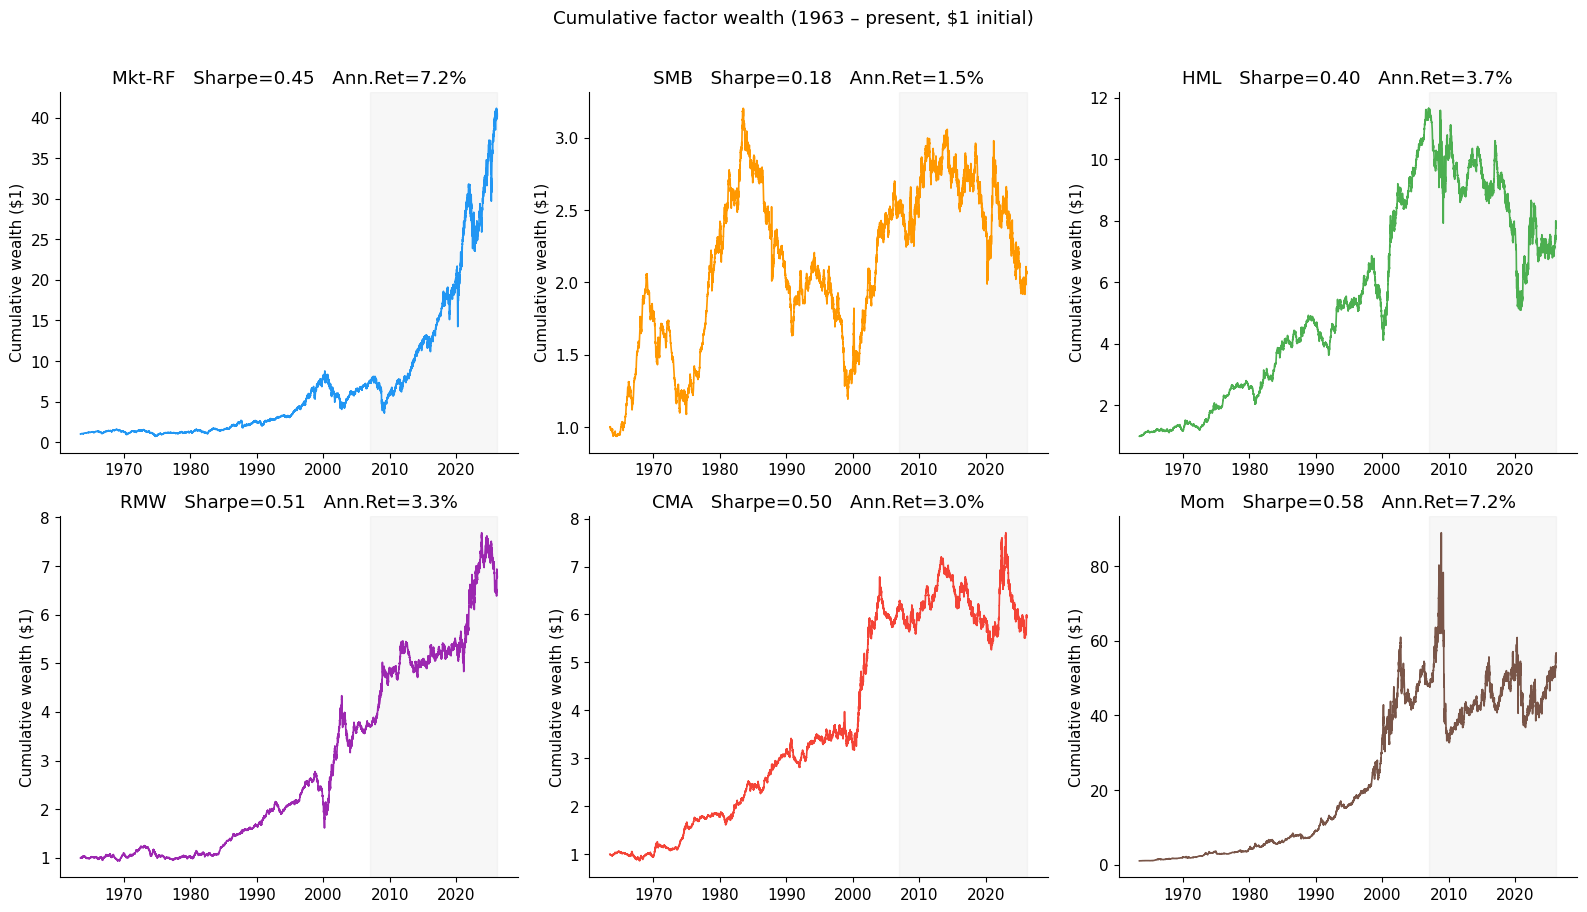

In [10]:
# Cumulative wealth from 1963 (FF5 start date)
f_post63 = f.loc['1963':]
cum = (1 + f_post63).cumprod()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336', '#795548']

for ax, col, color in zip(axes.flat, factor_cols, colors):
    ax.plot(cum[col], color=color, lw=1.2)
    ax.set_title(col)
    ax.set_ylabel('Cumulative wealth ($1)')
    # shade the post-2007 period where value has struggled
    ax.axvspan(pd.Timestamp('2007-01-01'), cum.index[-1],
               alpha=0.06, color='gray', label='Post-2007')
    ann_ret = f_post63[col].mean() * 252
    sharpe  = ann_ret / (f_post63[col].std() * np.sqrt(252))
    ax.set_title(f'{col}   Sharpe={sharpe:.2f}   Ann.Ret={ann_ret:.1%}')

plt.suptitle('Cumulative factor wealth (1963 – present, $1 initial)', y=1.01)
plt.tight_layout()
plt.show()

---
## 4 — Factor Correlations

Low factor correlations are what make the multi-factor model useful — each factor captures a distinct source of return variation.

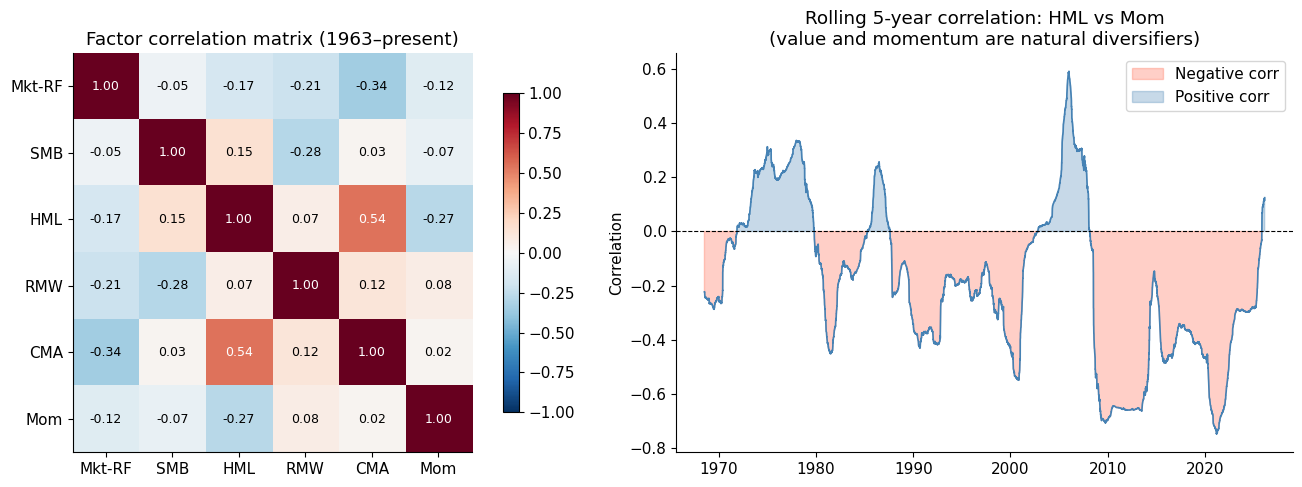

Unconditional correlations:
        Mkt-RF    SMB    HML    RMW    CMA    Mom
Mkt-RF   1.000 -0.051 -0.168 -0.213 -0.345 -0.120
SMB     -0.051  1.000  0.149 -0.282  0.027 -0.071
HML     -0.168  0.149  1.000  0.069  0.544 -0.274
RMW     -0.213 -0.282  0.069  1.000  0.123  0.076
CMA     -0.345  0.027  0.544  0.123  1.000  0.025
Mom     -0.120 -0.071 -0.274  0.076  0.025  1.000


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full history correlation
corr = f_post63[factor_cols].corr()

ax = axes[0]
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(factor_cols)))
ax.set_yticks(range(len(factor_cols)))
ax.set_xticklabels(factor_cols)
ax.set_yticklabels(factor_cols)
ax.set_title('Factor correlation matrix (1963–present)')
plt.colorbar(im, ax=ax, shrink=0.8)
for i in range(len(factor_cols)):
    for j in range(len(factor_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}",
                ha='center', va='center', fontsize=9,
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')

# Rolling 5-year correlation: HML vs Mom (notoriously negative during momentum crashes)
ax2 = axes[1]
roll_corr = f_post63['HML'].rolling(252*5).corr(f_post63['Mom'])
ax2.plot(roll_corr, color='steelblue', lw=1.2)
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.fill_between(roll_corr.index, roll_corr, 0,
                 where=(roll_corr < 0), color='tomato', alpha=0.3, label='Negative corr')
ax2.fill_between(roll_corr.index, roll_corr, 0,
                 where=(roll_corr > 0), color='steelblue', alpha=0.3, label='Positive corr')
ax2.set_title('Rolling 5-year correlation: HML vs Mom\n(value and momentum are natural diversifiers)')
ax2.set_ylabel('Correlation')
ax2.legend()

plt.tight_layout()
plt.show()

print('Unconditional correlations:')
print(corr.round(3).to_string())

---
## 5 — Connecting to Our Project

### Using French factors alongside yfinance data

The French data augments our yfinance price data in two concrete ways:

1. **Risk-free rate**: `factors_6f['RF']` is the daily risk-free rate. Use it to compute excess returns: `excess_ret = log_ret.sub(factors_6f['RF'], axis=0)`.

2. **Factor-adjusted alpha**: Run a time-series regression of each strategy's returns on the 6 factors. The intercept is the alpha that cannot be explained by the canonical factor premia.

In [12]:
# ── Load our universe (yfinance) and align with French factors ────────────────
try:
    log_returns = pd.read_parquet('../data/processed/log_returns.parquet')
    print(f'Loaded yfinance data: {log_returns.shape}')
except FileNotFoundError:
    print('yfinance data not found — run src/run_download_yahoo.py first.')
    log_returns = None

Loaded yfinance data: (2071, 15)


In [ ]:
if log_returns is not None:
    # Align date ranges
    factors_daily = loader.get_ff5_plus_mom(freq='daily')
    common_idx = log_returns.index.intersection(factors_daily.index)
    lr  = log_returns.loc[common_idx]
    fac = factors_daily.loc[common_idx]

    # Compute excess returns (subtract daily risk-free rate)
    excess_ret = lr.sub(fac['RF'], axis=0)

    print(f'\nAligned period: {common_idx[0].date()} → {common_idx[-1].date()}')
    print(f'Stocks: {list(lr.columns)}')
    print(f'\nFirst 3 rows of excess returns:')
    print(excess_ret.head(3).round(4).to_string())


Aligned period: 2018-01-03 → 2026-02-27
Stocks: ['AAPL', 'AMZN', 'CVX', 'GOOGL', 'GS', 'JPM', 'KO', 'LLY', 'META', 'MSFT', 'NVDA', 'PEP', 'PG', 'UNH', 'XOM']

First 3 rows of excess returns:
Ticker        AAPL    AMZN     CVX   GOOGL      GS     JPM      KO     LLY    META    MSFT    NVDA     PEP      PG     UNH     XOM
2018-01-03 -0.0003  0.0126  0.0072  0.0168 -0.0095  0.0009 -0.0023  0.0053  0.0177  0.0045  0.0636 -0.0027 -0.0013  0.0103  0.0193
2018-01-04  0.0045  0.0044 -0.0032  0.0038  0.0138  0.0141  0.0139  0.0044 -0.0019  0.0087  0.0052  0.0048  0.0069  0.0042  0.0013
2018-01-05  0.0112  0.0159 -0.0017  0.0131 -0.0052 -0.0065 -0.0003  0.0121  0.0135  0.0122  0.0083  0.0028  0.0006  0.0188 -0.0009


In [14]:
# ── 6-Factor alpha for each stock ─────────────────────────────────────────────
# Regress each stock's excess return on the 6 factors.
# Intercept = factor-adjusted alpha.

if log_returns is not None:
    factor_cols_6f = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
    X = np.column_stack([np.ones(len(fac)), fac[factor_cols_6f].values])

    alpha_results = {}
    for ticker in excess_ret.columns:
        y = excess_ret[ticker].values
        coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ coef
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        alpha_results[ticker] = {
            'alpha_ann': coef[0] * 252,
            'beta_Mkt':  coef[1],
            'beta_SMB':  coef[2],
            'beta_HML':  coef[3],
            'beta_RMW':  coef[4],
            'beta_CMA':  coef[5],
            'beta_Mom':  coef[6],
            'R2':        r2,
        }

    alpha_df = pd.DataFrame(alpha_results).T
    print('6-Factor model results (canonical French factors):')
    print(alpha_df.round(3).to_string())

6-Factor model results (canonical French factors):
       alpha_ann  beta_Mkt  beta_SMB  beta_HML  beta_RMW  beta_CMA  beta_Mom     R2
AAPL       0.025     1.239    -0.128    -0.539     0.534     0.386    -0.021  0.655
AMZN      -0.013     1.062    -0.226    -0.447     0.053    -0.817    -0.049  0.594
CVX       -0.039     0.997    -0.171     0.921    -0.349     0.311    -0.074  0.553
GOOGL      0.041     1.079    -0.170    -0.243     0.280    -0.580    -0.010  0.592
GS         0.017     1.174     0.012     0.898    -0.296    -0.352     0.053  0.703
JPM        0.011     1.073    -0.288     1.107    -0.319    -0.420    -0.044  0.746
KO        -0.009     0.583    -0.283     0.146     0.311     0.342    -0.122  0.383
LLY        0.195     0.715    -0.355    -0.207     0.008     0.615     0.036  0.197
META      -0.031     1.204    -0.195    -0.454     0.203    -0.727    -0.091  0.457
MSFT       0.003     1.143    -0.341    -0.313     0.298    -0.389     0.085  0.742
NVDA       0.174     1.74

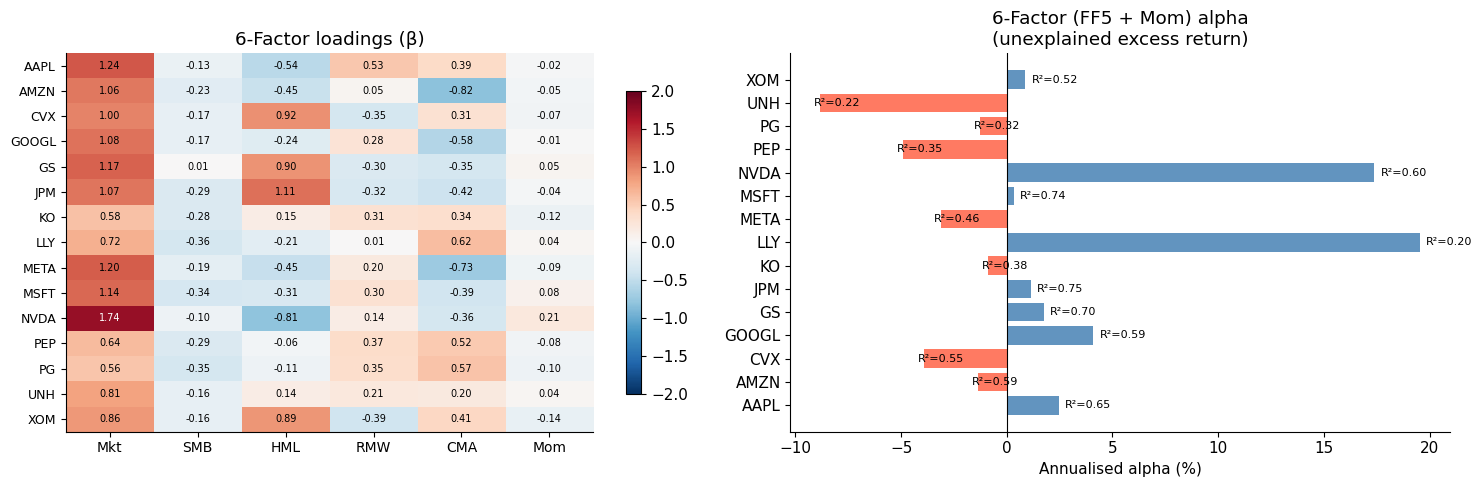


Key insight: stocks with near-zero 6F alpha are well-explained
by the canonical factor premia. Non-zero alpha = unexplained premium
(or data-mining artifact — use with caution).


In [16]:
# ── Plot: Factor loadings and 6F alpha ────────────────────────────────────────
if log_returns is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Heatmap of factor loadings
    ax = axes[0]
    load_cols = ['beta_Mkt', 'beta_SMB', 'beta_HML', 'beta_RMW', 'beta_CMA', 'beta_Mom']
    loadings = alpha_df[load_cols]
    im = ax.imshow(loadings.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    ax.set_xticks(range(6))
    ax.set_xticklabels(['Mkt', 'SMB', 'HML', 'RMW', 'CMA', 'Mom'], fontsize=10)
    ax.set_yticks(range(len(alpha_df)))
    ax.set_yticklabels(alpha_df.index, fontsize=9)
    ax.set_title('6-Factor loadings (β)')
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(len(alpha_df)):
        for j, col in enumerate(load_cols):
            val = loadings.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=7, color='white' if abs(val) > 1.3 else 'black')

    # Annualised 6F alpha
    ax2 = axes[1]
    colors_bar = ['steelblue' if v >= 0 else 'tomato' for v in alpha_df['alpha_ann']]
    ax2.barh(alpha_df.index, alpha_df['alpha_ann'] * 100, color=colors_bar, alpha=0.85)
    ax2.axvline(0, color='black', lw=0.8)
    ax2.set_xlabel('Annualised alpha (%)')
    ax2.set_title('6-Factor (FF5 + Mom) alpha\n(unexplained excess return)')
    for i, (idx, row) in enumerate(alpha_df.iterrows()):
        ax2.text(row['alpha_ann'] * 100 + (0.3 if row['alpha_ann'] >= 0 else -0.3),
                 i, f"R²={row['R2']:.2f}", va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    print('\nKey insight: stocks with near-zero 6F alpha are well-explained')
    print('by the canonical factor premia. Non-zero alpha = unexplained premium')
    print('(or data-mining artifact — use with caution).')